# Subset Extended IBTrACS

In [1]:
# Setup environment
import huracanpy
import numpy as np
import xarray as xr
from shapely import Polygon, Point
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
# Script parameters
IN_FILE = "../files/extended_ibtracs_ibattrs.nc"

In [3]:
# Open extended IBTrACS
eib = xr.open_dataset(IN_FILE)
eib

<xarray.Dataset> Size: 83MB
Dimensions:     (record: 188964, dataset: 6)
Coordinates:
  * dataset     (dataset) <U17 408B 'IBTrACS' ... 'TRACK-ECMWF-OP-AN'
  * record      (record) int64 2MB 0 1 2 3 4 ... 188960 188961 188962 188963
Data variables: (12/19)
    track_id    (record) <U13 10MB ...
    lon         (dataset, record) float64 9MB ...
    lat         (dataset, record) float64 9MB ...
    name        (record) <U13 10MB ...
    pres        (dataset, record) float64 9MB ...
    wind10      (dataset, record) float64 9MB ...
    ...          ...
    usa_sshs    (record) float64 2MB ...
    usa_poci    (record) float64 2MB ...
    usa_roci    (record) float64 2MB ...
    usa_rmw     (record) float64 2MB ...
    usa_eye     (record) float64 2MB ...
    usa_gust    (record) float64 2MB ...

## Subset tracks by time and dataset
In this example, we extract the 1980-2022 period, and only the ERA5 and JRA3Q which cover homogeneously this period.

In [4]:
valid_ds = ["IBTrACS", "SyCLoPS-ERA5", "TRACK-ERA5", "TRACK-JRA3Q"] # List of datasets to keep

In [5]:
# Subsetting
eib_1980_2022 = eib.where(
                            (eib.time.dt.year >= 1980) & (eib.time.dt.year <= 2022), drop = True
                         ).sel(dataset = valid_ds)
eib_1980_2022

<xarray.Dataset> Size: 19MB
Dimensions:     (record: 73624, dataset: 4)
Coordinates:
  * dataset     (dataset) <U17 272B 'IBTrACS' 'SyCLoPS-ERA5' ... 'TRACK-JRA3Q'
  * record      (record) int64 589kB 70273 70274 70275 ... 188802 188803 188804
Data variables: (12/19)
    track_id    (record) object 589kB '1980199N31284' ... '1988248N28267'
    lon         (dataset, record) float64 2MB nan nan nan nan ... nan nan nan
    lat         (dataset, record) float64 2MB nan nan nan nan ... nan nan nan
    name        (record) object 589kB 'UNNAMED' 'UNNAMED' ... 'UNNAMED'
    pres        (dataset, record) float64 2MB nan nan nan nan ... nan nan nan
    wind10      (dataset, record) float64 2MB nan nan nan nan ... nan nan nan
    ...          ...
    usa_sshs    (record) float64 589kB nan nan nan nan ... -1.0 -1.0 -1.0 -1.0
    usa_poci    (record) float64 589kB nan nan nan nan nan ... nan nan nan nan
    usa_roci    (record) float64 589kB nan nan nan nan nan ... nan nan nan nan
    usa_rmw     (record) float64 589kB nan nan nan nan nan ... nan nan nan nan
    usa_eye     (record) float64 589kB nan nan nan nan nan ... nan nan nan nan
    usa_gust    (record) float64 589kB nan nan nan nan nan ... nan nan nan nan

## Subset tracks by attribute
In this example, we subset the tracks that reached the TS intensity at least once while tropical.

In [6]:
valid_status = ["TS", "TC", "HU", "HR"] # List of values for "usa_status" that correspond to tropical and TS intensity or more

In [7]:
# Subsetting
eib_1980_2022_TS = eib_1980_2022.hrcn.trackswhere(lambda t: t.usa_status.isin(valid_status).any())
eib_1980_2022_TS

<xarray.Dataset> Size: 16MB
Dimensions:     (record: 64408, dataset: 4)
Coordinates:
  * dataset     (dataset) <U17 272B 'IBTrACS' 'SyCLoPS-ERA5' ... 'TRACK-JRA3Q'
  * record      (record) int64 515kB 70740 70741 70742 ... 142214 142215 142216
Data variables: (12/19)
    track_id    (record) object 515kB '1980214N11330' ... '2022311N21293'
    lon         (dataset, record) float64 2MB nan nan nan nan ... nan -53.46 nan
    lat         (dataset, record) float64 2MB nan nan nan nan ... nan 47.81 nan
    name        (record) object 515kB 'ALLEN' 'ALLEN' ... 'NICOLE' 'NICOLE'
    pres        (dataset, record) float64 2MB nan nan nan nan ... nan 988.8 nan
    wind10      (dataset, record) float64 2MB nan nan nan nan ... nan 24.7 nan
    ...          ...
    usa_sshs    (record) float64 515kB nan nan nan nan nan ... nan nan nan nan
    usa_poci    (record) float64 515kB nan nan nan nan nan ... nan nan nan nan
    usa_roci    (record) float64 515kB nan nan nan nan nan ... nan nan nan nan
    usa_rmw     (record) float64 515kB nan nan nan nan nan ... nan nan nan nan
    usa_eye     (record) float64 515kB nan nan nan nan nan ... nan nan nan nan
    usa_gust    (record) float64 515kB nan nan nan nan nan ... nan nan nan nan

## Subset tracks by zone

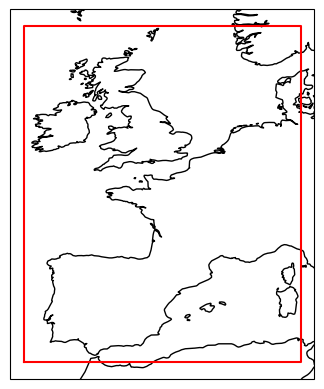

In [8]:
# Define shapely polygon
zone = Polygon(((-11,35.5),(-11,61),(10,61),(10,35.5)))
# Plot zone boundary
ax = plt.axes(projection = ccrs.PlateCarree())
ax.coastlines()
ax.plot(*zone.exterior.xy, color = "red")

In [9]:
# Flag points within the zone
is_zone = lambda lon, lat : zone.contains(Point(lon, lat))
eib_1980_2022_TS["in_zone"] = xr.apply_ufunc(np.vectorize(is_zone), eib_1980_2022_TS.lon, eib_1980_2022_TS.lat)

In [10]:
# Subset cyclones that have at least one point from one dataset in the zone
zone_reaching = eib_1980_2022_TS.hrcn.trackswhere(lambda t: t.in_zone.any())
zone_reaching

<xarray.Dataset> Size: 4MB
Dimensions:     (record: 14318, dataset: 4)
Coordinates:
  * dataset     (dataset) <U17 272B 'IBTrACS' 'SyCLoPS-ERA5' ... 'TRACK-JRA3Q'
  * record      (record) int64 115kB 70560 70561 70562 ... 142128 142129 142130
Data variables: (12/20)
    track_id    (record) object 115kB '1980227N13325' ... '2022304N34296'
    lon         (dataset, record) float64 458kB nan nan nan nan ... nan nan nan
    lat         (dataset, record) float64 458kB nan nan nan nan ... nan nan nan
    name        (record) object 115kB 'BONNIE' 'BONNIE' ... 'MARTIN' 'MARTIN'
    pres        (dataset, record) float64 458kB nan nan nan nan ... nan nan nan
    wind10      (dataset, record) float64 458kB nan nan nan nan ... nan nan nan
    ...          ...
    usa_poci    (record) float64 115kB nan nan nan nan nan ... nan nan nan nan
    usa_roci    (record) float64 115kB nan nan nan nan nan ... nan nan nan nan
    usa_rmw     (record) float64 115kB nan nan nan nan nan ... nan nan nan nan
    usa_eye     (record) float64 115kB nan nan nan nan nan ... nan nan nan nan
    usa_gust    (record) float64 115kB nan nan nan nan nan ... nan nan nan nan
    in_zone     (dataset, record) bool 57kB False False False ... False False

In [11]:
# Save
zone_reaching.to_netcdf("../files/extended_ibtracs_TS_1980-2022_reaching_BIWE.nc")

## Subset tracks by country reached

In [12]:
# Identify country for each point
C = []
for ds in eib_1980_2022_TS.dataset.values:
    C.append(eib_1980_2022_TS.sel(dataset = ds).hrcn.get_country())
eib_1980_2022_TS["country"] = xr.concat(C, dim = "dataset")

In [13]:
# Subsetting
country = "France"
country_reaching = eib_1980_2022_TS.hrcn.trackswhere(lambda t: ((t.country == country) & (t.in_zone)).any()) 
# NB: In that case, we add a condition that tracks must be within the european zone defined above because France has oversea territories.

In [14]:
country_reaching

<xarray.Dataset> Size: 2MB
Dimensions:     (record: 2545, dataset: 4)
Coordinates:
  * dataset     (dataset) <U17 272B 'IBTrACS' 'SyCLoPS-ERA5' ... 'TRACK-JRA3Q'
  * record      (record) int64 20kB 73022 73023 73024 ... 138235 138236 138237
Data variables: (12/21)
    track_id    (record) object 20kB '1981265N14328' ... '2021165N32282'
    lon         (dataset, record) float64 81kB nan nan nan nan ... nan nan nan
    lat         (dataset, record) float64 81kB nan nan nan nan ... nan nan nan
    name        (record) object 20kB 'IRENE' 'IRENE' 'IRENE' ... 'BILL' 'BILL'
    pres        (dataset, record) float64 81kB nan nan nan nan ... nan nan nan
    wind10      (dataset, record) float64 81kB nan nan nan nan ... nan nan nan
    ...          ...
    usa_roci    (record) float64 20kB nan nan nan nan nan ... nan nan nan nan
    usa_rmw     (record) float64 20kB nan nan nan nan nan ... nan nan nan nan
    usa_eye     (record) float64 20kB nan nan nan nan nan ... nan nan nan nan
    usa_gust    (record) float64 20kB nan nan nan nan nan ... nan nan nan nan
    in_zone     (dataset, record) bool 10kB False False False ... False False
    country     (dataset, record) <U24 977kB '' '' '' '' '' ... '' '' '' '' ''

In [15]:
# Save
zone_reaching.to_netcdf("../files/extended_ibtracs_TS_1980-2022_reaching_"+country+".nc")